In [1]:
# phase2_ml_pipeline.ipynb

# 📌 Step 1: Imports
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 📌 Step 2: Generate Synthetic Data

np.random.seed(42)

n_samples = 1000
sex = np.random.choice(['Male', 'Female'], n_samples)
age = np.random.randint(18, 90, n_samples)
systolic_bp = np.random.randint(90, 180, n_samples)
diastolic_bp = np.random.randint(60, 110, n_samples)
heart_rate = np.random.randint(50, 130, n_samples)
has_diabetes = np.random.choice([0, 1], n_samples)
has_heart_disease = np.random.choice([0, 1], n_samples)
symptom_fever = np.random.choice([0, 1], n_samples)
symptom_cough = np.random.choice([0, 1], n_samples)

# Labels: simulated "next best action"
actions = ['Order CBC', 'Order Chest X-ray', 'Start IV Fluids', 'CT Scan', 'ECG']
next_action = np.random.choice(actions, n_samples, p=[0.3, 0.2, 0.2, 0.2, 0.1])

df = pd.DataFrame({
    'sex': sex,
    'age': age,
    'systolic_bp': systolic_bp,
    'diastolic_bp': diastolic_bp,
    'heart_rate': heart_rate,
    'has_diabetes': has_diabetes,
    'has_heart_disease': has_heart_disease,
    'symptom_fever': symptom_fever,
    'symptom_cough': symptom_cough,
    'next_action': next_action
})

df.head()


,sex,age,systolic_bp,diastolic_bp,heart_rate,has_diabetes,has_heart_disease,symptom_fever,symptom_cough,next_action
0,Male,80,103,108,121,0,1,1,0,Order Chest X-ray
1,Female,34,178,61,94,1,1,0,0,CT Scan
2,Male,50,173,84,108,1,1,1,0,Order CBC
3,Male,46,91,62,53,1,0,0,1,CT Scan
4,Male,30,159,67,116,1,0,1,0,Order CBC


In [3]:
# 📌 Step 3: Preprocessing

# Encode categorical columns
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])  # Male=1, Female=0

le_action = LabelEncoder()
df['next_action_encoded'] = le_action.fit_transform(df['next_action'])

X = df.drop(['next_action', 'next_action_encoded'], axis=1)
y = df['next_action_encoded']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [4]:
# 📌 Step 4: Train Baseline Model

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Classification Report:
                   precision    recall  f1-score   support

          CT Scan       0.16      0.14      0.15        36
              ECG       0.50      0.14      0.21        22
        Order CBC       0.36      0.58      0.44        62
Order Chest X-ray       0.20      0.18      0.19        38
  Start IV Fluids       0.15      0.10      0.12        42

         accuracy                           0.28       200
        macro avg       0.27      0.23      0.22       200
     weighted avg       0.26      0.28      0.25       200



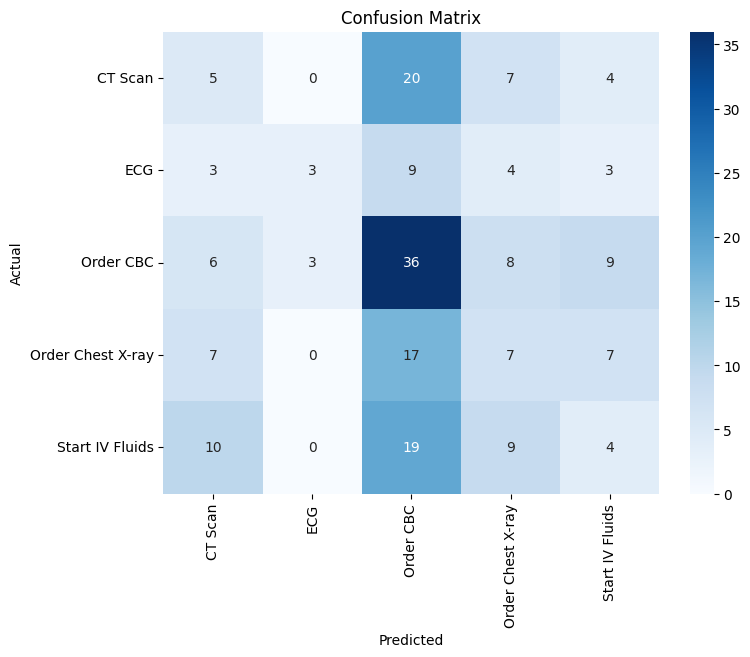

In [5]:
# 📌 Step 5: Evaluation

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_action.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_action.classes_, yticklabels=le_action.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [8]:
# 📌 Step 6: Example Dynamic Update (Simulate new data)

# Simulate a new patient
new_patient = pd.DataFrame([{
    'sex': le_sex.transform(['Male'])[0],
    'age': 66,
    'systolic_bp': 150,
    'diastolic_bp': 95,
    'heart_rate': 110,
    'has_diabetes': 1,
    'has_heart_disease': 1,
    'symptom_fever': 1,
    'symptom_cough': 1
}])

new_patient_scaled = scaler.transform(new_patient)
pred_idx = clf.predict(new_patient_scaled)[0]
pred_action = le_action.inverse_transform([pred_idx])[0]

print("📍 Recommended next clinical step:", pred_action)

📍 Recommended next clinical step: Order CBC
